# **IIITH RAP Phase-II Internship Project**

# Multimodal Emotion Recognition using Speech and Text Fusion

---

## Project Overview

This project focuses on developing a multimodal deep learning framework capable of recognizing human emotions using both speech and textual modalities.

The system integrates:

- Acoustic feature learning from speech signals
- Semantic understanding from transcript text
- Feature-level multimodal fusion for enhanced emotion recognition

The project is implemented using:

- PyTorch
- Librosa
- HuggingFace Transformers
- Google Colab

---

## Objectives

The primary objectives of this project are:

1. Build a speech-based emotion recognition model
2. Build a text-based emotion recognition model
3. Combine both modalities using fusion learning
4. Analyze emotional separability using learned embeddings
5. Compare unimodal and multimodal performance

---

## Dataset

Dataset Used:
### Toronto Emotional Speech Set (TESS)

The dataset contains:

- Speech audio samples
- Corresponding transcripts
- Emotion labels

Target emotions include:

- Angry
- Disgust
- Fear
- Happy
- Neutral
- Pleasant Surprise
- Sad

# **Phase 1 — Project Initialization and Environment Setup**

This phase includes:

- Google Drive integration
- Folder structure creation
- Dependency installation
- Environment verification
- Dataset organization

The goal of this phase is to establish a clean and modular project structure for subsequent deep learning experiments.

In [31]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Creating Project Directory Structure

A modular directory structure is essential for maintaining readability, reproducibility, and scalability in deep learning projects.

The following directories will be created:

- notebooks
- dataset
- models
- results
- exports
- saved_models
- app

This structure ensures proper separation of:

- training scripts
- saved checkpoints
- visualizations
- deployment files
- experimental outputs

In [32]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition"

folders = [
    "notebooks",
    "dataset",
    "models",
    "models/speech_pipeline",
    "models/text_pipeline",
    "models/fusion_pipeline",
    "results",
    "results/confusion_matrices",
    "results/tsne_visualizations",
    "results/training_curves",
    "results/model_reports",
    "saved_models",
    "exports",
    "app"
]
for folder in folders:
    folder_path = os.path.join(
        PROJECT_PATH,
        folder
    )
    os.makedirs(
        folder_path,
        exist_ok=True
    )
print("Project Structure Created Successfully")

Project Structure Created Successfully


# Installing Required Dependencies

The project uses multiple libraries for:

- speech processing
- deep learning
- NLP
- visualization
- evaluation

The following libraries will be installed:

- librosa
- transformers
- torch
- torchaudio
- seaborn
- scikit-learn

In [33]:
!pip install librosa transformers seaborn -q

# Importing Core Libraries

This section imports all primary libraries required for:

- data processing
- feature extraction
- visualization
- neural network training
- evaluation

In [34]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from transformers import (
    DistilBertTokenizer,
    DistilBertModel
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Verifying GPU Availability

Deep learning training becomes significantly faster when executed using GPU acceleration.

This section verifies whether CUDA-enabled GPU support is available in the runtime environment.

In [35]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print("Using Device:", device)

Using Device: cuda


# Dataset Path Configuration

The TESS dataset is stored inside Google Drive.

This section defines the dataset directory path that will be used throughout the project pipeline.

In [36]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition"
print(DATASET_PATH)

/content/drive/MyDrive/Colab Notebooks/IIITH_RAP_Multimodal_Emotion_Recognition


# **Phase 2 — Dataset Preparation and Metadata Construction**

A structured metadata pipeline is essential for multimodal deep learning systems.

This phase performs:

- audio file discovery
- transcript extraction
- emotion label generation
- metadata dataframe creation
- dataset validation
- train/validation/test split

The generated dataframe will act as the central reference structure for all subsequent speech, text, and fusion pipelines.

# Discovering Audio Files

The TESS dataset contains multiple folders corresponding to different speakers and emotional categories.

This section recursively scans the dataset directory and identifies all valid audio files for processing.

In [37]:
audio_files = []
for root, directories, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(
                root,
                file
            )
            audio_files.append(file_path)
print("Total Audio Files Found:")
print(len(audio_files))

Total Audio Files Found:
2800


# Understanding TESS File Naming Convention

Each audio filename in the TESS dataset follows a structured naming format.

Example:

OAF_back_angry.wav

This filename contains:

- speaker identifier
- transcript word
- emotion label

The filename structure enables automatic extraction of:

- transcript text
- emotion category

In [38]:
sample_file = os.path.basename(
    audio_files[0]
)
print("Sample Filename:")
print(sample_file)

Sample Filename:
YAF_juice_disgust.wav


# Extracting Metadata from Audio Filenames

This section parses each filename and extracts:

- audio path
- transcript text
- emotion label

The extracted information is stored inside a structured dataframe for downstream model training.

In [39]:
metadata_rows = []
for file_path in audio_files:
    filename = os.path.basename(file_path)
    filename = filename.replace(
        ".wav",
        ""
    )
    parts = filename.split("_")
    speaker_id = parts[0]
    transcript = parts[1].lower()
    emotion = "_".join(parts[2:]).lower()
    emotion = emotion.replace(
        "pleasant_surprised",
        "pleasant_surprise"
    )
    metadata_rows.append({
        "audio_path": file_path,
        "speaker_id": speaker_id,
        "transcript": transcript,
        "emotion": emotion
    })
print("Metadata Extraction Completed")

Metadata Extraction Completed


# Constructing the Dataset DataFrame

A pandas dataframe is used to organize all extracted metadata into a structured tabular format.

The dataframe contains:

- audio paths
- speaker identifiers
- transcript text
- emotion labels

In [40]:
df = pd.DataFrame(metadata_rows)
print("Dataset DataFrame Created Successfully")
print()
df.head()

Dataset DataFrame Created Successfully



,audio_path,speaker_id,transcript,emotion
0,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,juice,disgust
1,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,laud,disgust
2,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,bar,disgust
3,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,rot,disgust
4,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,bean,disgust


# Verifying Dataset Integrity

Before training deep learning models, it is important to verify that:

- all rows contain valid values
- no missing data exists
- emotion labels are consistent

In [41]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

audio_path    0
speaker_id    0
transcript    0
emotion       0
dtype: int64


# Exploring Emotion Categories

This section identifies all unique emotion labels present in the dataset.

In [42]:
emotion_classes = sorted(
    df["emotion"].unique()
)
print("Emotion Categories:\n")
for emotion in emotion_classes:
    print("-", emotion)

Emotion Categories:

- angry
- disgust
- fear
- happy
- neutral
- ps
- sad


# Visualizing Emotion Distribution

Balanced class distribution is important for stable deep learning training.

This visualization helps identify whether the dataset contains class imbalance.

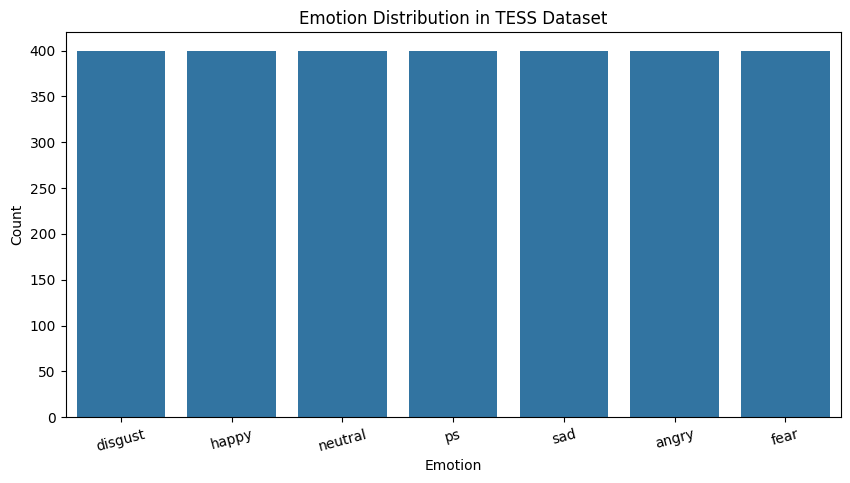

In [43]:
plt.figure(figsize=(10,5))
sns.countplot(
    x=df["emotion"],
    order=df["emotion"].value_counts().index
)
plt.title("Emotion Distribution in TESS Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

# Encoding Emotion Labels

Deep learning models operate on numerical labels rather than categorical text labels.

This section converts emotion categories into numerical representations using label encoding.

In [44]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(
    df["emotion"]
)
print("Label Encoding Completed")
print()
df.head()

Label Encoding Completed



,audio_path,speaker_id,transcript,emotion,label
0,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,juice,disgust,1
1,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,laud,disgust,1
2,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,bar,disgust,1
3,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,rot,disgust,1
4,/content/drive/MyDrive/Colab Notebooks/IIITH_R...,YAF,bean,disgust,1


# Label Mapping

The following mapping defines the relationship between emotion categories and their encoded numerical labels.

In [45]:
label_mapping = {
    emotion: index
    for index, emotion in enumerate(
        label_encoder.classes_
    )
}
print(label_mapping)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'ps': 5, 'sad': 6}


# Train / Validation / Test Split

The dataset is divided into:

- Training Set
- Validation Set
- Test Set

Purpose of each split:

Training Set:
Used for model learning

Validation Set:
Used for hyperparameter tuning and overfitting prevention

Test Set:
Used for final unbiased evaluation

In [46]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label"],
    random_state=42
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df["label"],
    random_state=42
)
print("Dataset Split Completed")

Dataset Split Completed


# Dataset Split Statistics

This section verifies the number of samples present in:

- training set
- validation set
- test set

In [47]:
print("Training Samples:", len(train_df))
print("Validation Samples:", len(val_df))
print("Test Samples:", len(test_df))

Training Samples: 2023
Validation Samples: 357
Test Samples: 420


# Verifying Class Balance Across Splits

Maintaining balanced class distribution across train, validation, and test sets is important for fair evaluation.

In [48]:
print("Training Distribution:\n")
print(train_df["emotion"].value_counts())
print("\nValidation Distribution:\n")
print(val_df["emotion"].value_counts())
print("\nTest Distribution:\n")
print(test_df["emotion"].value_counts())

Training Distribution:

emotion
disgust    289
happy      289
sad        289
angry      289
ps         289
fear       289
neutral    289
Name: count, dtype: int64

Validation Distribution:

emotion
sad        51
happy      51
ps         51
angry      51
neutral    51
disgust    51
fear       51
Name: count, dtype: int64

Test Distribution:

emotion
sad        60
disgust    60
angry      60
happy      60
ps         60
neutral    60
fear       60
Name: count, dtype: int64


# Saving Processed Metadata

The processed metadata dataframe is saved for reproducibility and future experiments.

In [49]:
metadata_save_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "tess_metadata.csv"
)
df.to_csv(
    metadata_save_path,
    index=False
)
print("Metadata CSV Saved Successfully")

Metadata CSV Saved Successfully


# Saving Label Encoder

The label encoder is saved to preserve consistent label mappings during future inference and deployment.

In [50]:
import pickle
label_encoder_path = os.path.join(
    PROJECT_PATH,
    "exports",
    "label_encoder.pkl"
)
with open(label_encoder_path, "wb") as file:
    pickle.dump(
        label_encoder,
        file
    )
print("Label Encoder Saved Successfully")

Label Encoder Saved Successfully


# Phase 2 Summary

This phase successfully completed:

- dataset discovery
- metadata generation
- transcript extraction
- label encoding
- train/validation/test split
- dataset verification
- metadata export

The prepared dataframe will now be used for:

- speech emotion recognition
- text emotion recognition
- multimodal fusion learning